 ## Data Inspection

In [2]:
# Importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [4]:
# loading the datasets
df = pd.read_csv('Downloads/heart.csv')

In [5]:
# display first 10 rows
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [8]:
df.shape

(918, 12)

In [9]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [10]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [12]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [50]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
count,9.180000e+02,918.000000,9.180000e+02,9.180000e+02,918.000000,9.180000e+02,918.000000,9.180000e+02,918.000000
mean,-1.083616e-16,0.789760,2.747742e-16,-2.883194e-16,0.233115,4.953675e-16,0.404139,4.644070e-17,0.553377
std,1.000545e+00,0.407701,1.000545e+00,1.000545e+00,0.423046,1.000545e+00,0.490992,1.000545e+00,0.497414
min,-2.706015e+00,0.000000,-3.075810e+00,-3.413848e+00,0.000000,-3.018469e+00,0.000000,-3.368422e+00,0.000000
25%,-6.906294e-01,1.000000,-7.169675e-01,-5.905922e-01,0.000000,-6.605778e-01,0.000000,-8.499008e-01,0.000000
50%,5.188098e-02,1.000000,-1.272568e-01,-8.722098e-02,0.000000,4.678968e-02,0.000000,-2.687035e-01,1.000000
75%,6.883185e-01,1.000000,4.624540e-01,5.693502e-01,0.000000,7.541571e-01,1.000000,6.030924e-01,1.000000
max,2.491558e+00,1.000000,2.231586e+00,2.309264e+00,1.000000,2.561874e+00,1.000000,2.782582e+00,1.000000


In [13]:
# checking for disguised data 
print("Cholesterol == 0:", (df['Cholesterol'] == 0).sum())
print("RestingBP == 0:", (df['RestingBP'] == 0).sum())

Cholesterol == 0: 172
RestingBP == 0: 1


**Insights**: Cholesterol initially showed no null values. However, there is a possibility that there are missing values written as 0

## Data Cleaning 

In [14]:
# Treat '0' in Cholesterol/RestingBP as missing, then convert to missing values
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

In [15]:
# replacing the missing values with the median
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())


**Insights** : The median was used to replace the missing values as it is not mostly affected by extreme values or outliers

In [21]:
# dropping duplicates if any
df = df.drop_duplicates()

In [22]:
# saving cleaned dataset 
df_cleaned = df.copy()

## Feature Engineering

In [23]:
# creating new column: Age band
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,40,55,70,100],
                         labels=['<40','40-55','55-70','70+'])

**Insights**: A new column called "Age group' was created from the Age column. This is useful because it is easier to evaluate and analyze than raw ages

## Feature Encoding

In [25]:
# Binary categoricals converted using Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])                   
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])  

**Insights**: 'Sex' and 'ExerciseAngina' are binary with no ordering (i.e M/F, Yes/No), so Label encoding is sufficient as it avoids dimensionality

In [30]:
# Nominal (no particular order) → One-Hot Encoding
df = pd.get_dummies(df, columns=['ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up', 'AgeGroup_40-55', 'AgeGroup_55-70', 'AgeGroup_70+'],
                     drop_first=True)

**Insights**: Categorical variables without a particular order are encoded using one-hot encoding. One-Hot Encoding avoids implying a false ordinal relationship that Label Encoding would introduce.

## Outlier detection

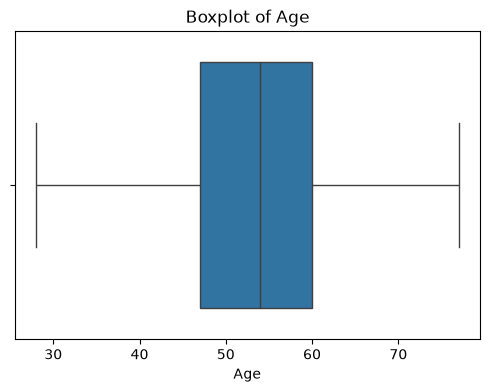

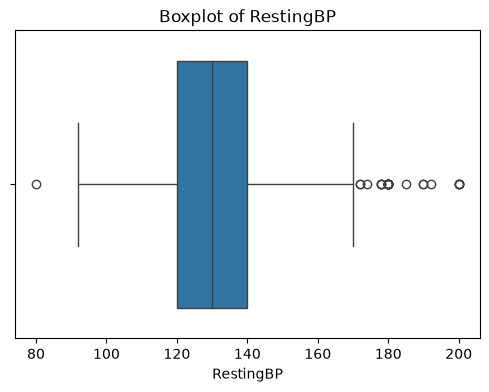

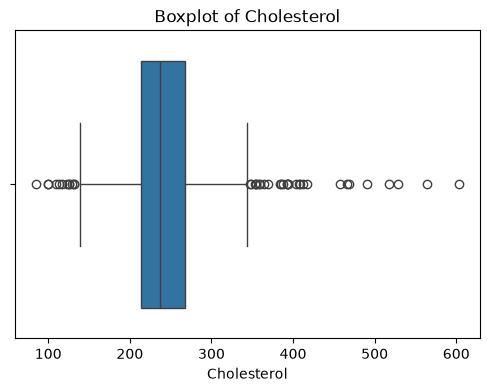

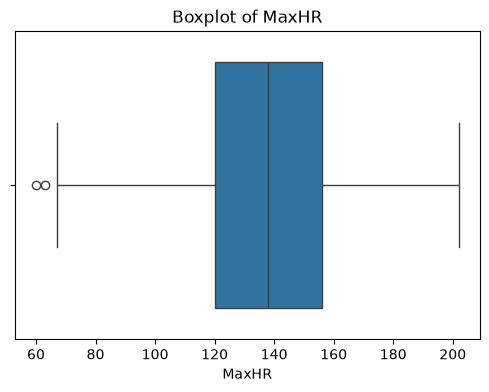

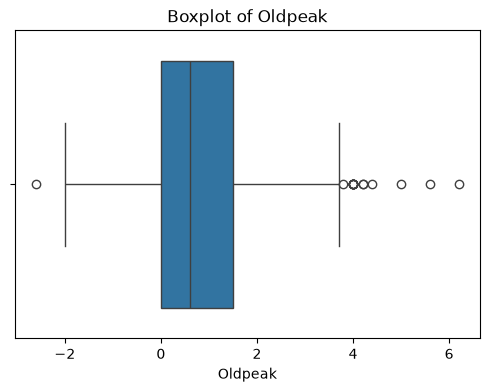

In [32]:
num_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

**Insights**: The following boxplots show how each numerical feature is spread out and where we have high values

In [34]:
# Handling outliers with IQR
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['Cholesterol'] = np.where(df['Cholesterol'] > upper, upper, df['Cholesterol'])

In [35]:
Q1 = df['RestingBP'].quantile(0.25)
Q3 = df['RestingBP'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['RestingBP'] = np.where(df['RestingBP'] > upper, upper, df['RestingBP'])

In [37]:
Q1 = df['Oldpeak'].quantile(0.25)
Q3 = df['Oldpeak'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['Oldpeak'] = np.where(df['Oldpeak'] > upper, upper, df['Oldpeak'])

**Insights**: Only columns that have shown to have outliers (Cholesterol, RestingBP, and Oldpeak) that were handled.

## Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

**Insights**: StandardScaler is appropriate for this project because it involves numeric columns like Age, RestingBP, Cholesterol, MaxHR, and OldPeak, and placing these features on the same scale by giving them a mean of 0 and a standard deviation of 1. 

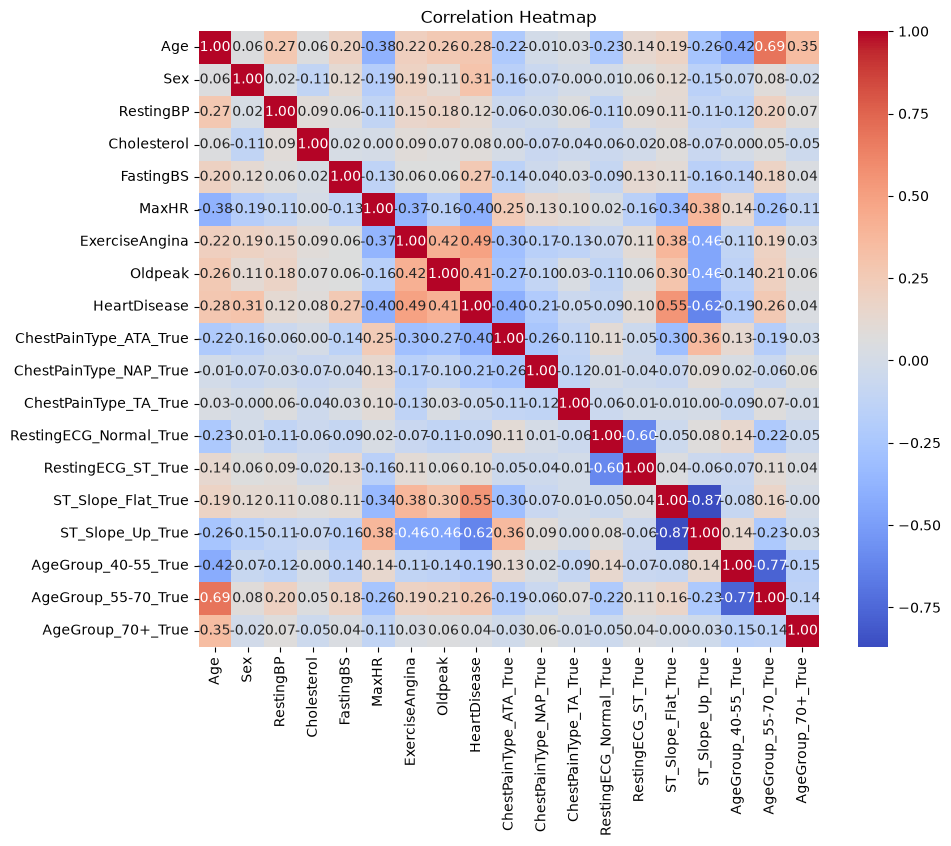

In [40]:
# showing the correlation heat map
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

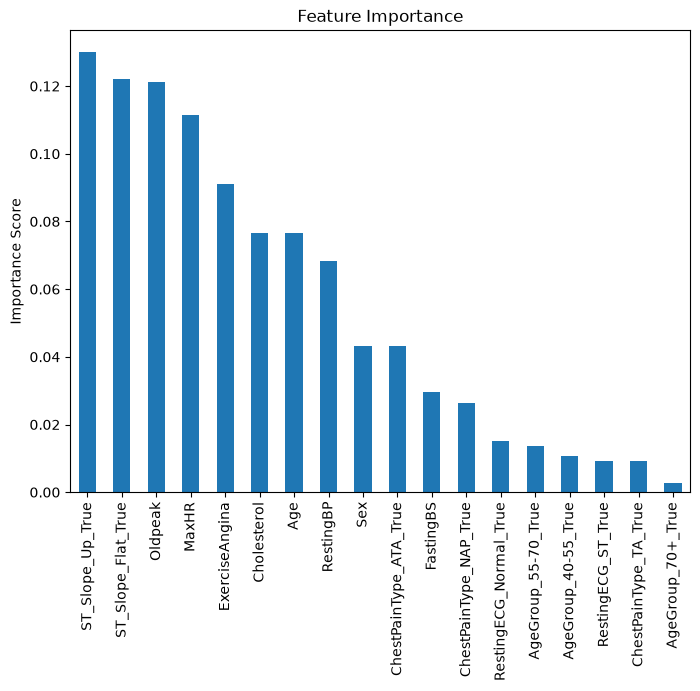

In [44]:
#importing Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(8,6))
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.show()

**Insights**: The chart shows that ST_Slope_Up_True, ST_Slope_Flat_True, and Oldpeak had the highest feature importance score

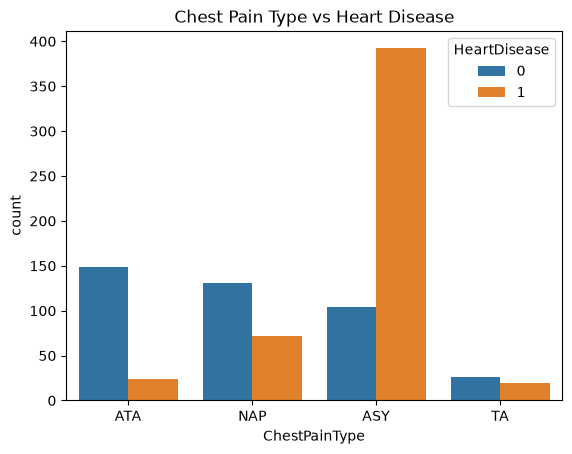

In [45]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df_cleaned)
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

**Insights**: The countplot suggests that heart disease is more common in the ASY chest pain group than in the other chest pain types. The ATA and NAP groups appear to have more people without heart disease.

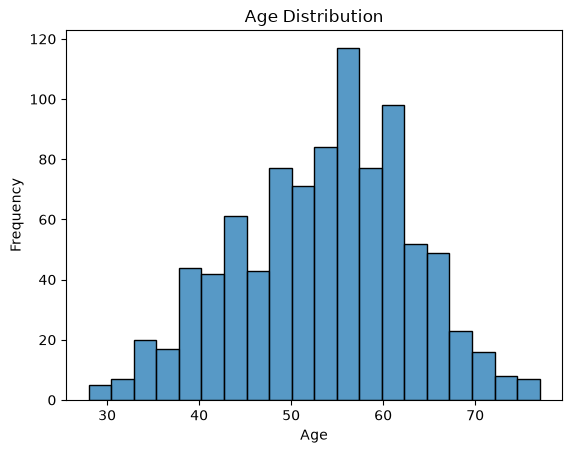

In [46]:
sns.histplot(df_cleaned['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Insights**: This shows that the dataset is mostly made up of middle-aged and older adults, with the highest concentration around the 40–60 age range. There are fewer younger people and the distribution thins out at the higher ages.

In [47]:
# exporting cleaned dataset
df_cleaned.to_csv('cleaned_dataset.csv', index=False)

In [49]:
# exporting ml-ready dataset
df.to_csv('ml_ready_dataset.csv', index=False)